# ⚽ AI Tactical Scouting Engine: Deep Manifold Mapping
**Author:** Juan Pablo Martínez Cordeiro | **Project:** `ftbl-fingerprint`

## 📖 Executive Summary
Traditional football scouting relies heavily on volume statistics (e.g., total passes, total tackles). However, a player who completes 50 passes hugging the left touchline plays a fundamentally different role than a player completing 50 passes in the central "Zone 14" pocket.

This notebook demonstrates the construction of a **112+ Dimensional Tactical Fingerprint** for elite players using:
1. **Custom Kinematics:** First and second temporal derivatives of coordinate data to measure bursts, velocity, and deceleration.
2. **Finite Spatial Meshes:** Discretizing continuous GPS locations into high-resolution tactical grids.
3. **Deep Non-Linear Manifolds (VAE):** Folding a sparse 400-dimensional matrix into a dense 16-dimensional latent space using PyTorch, achieving a mathematical Separation Ratio > 2.0x.

In [3]:
import sys
import os
# Force Python to look in both the current and parent directories for the 'src' folder
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('..'))

# System & Data
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
from mplsoccer import Pitch

# ML & Deep Learning
import torch
from sklearn.preprocessing import StandardScaler

# Custom Pipeline Modules
from src.data_fetching import build_league_dataset
from src.ml_models import train_and_extract_vae
from src.linear_models import train_and_extract_pca
from src.verification_validation import evaluate_manifold_stability, run_mesh_convergence

---
## Phase 1: Finite Element Mesh Convergence (Spatial Discretization)
Before we can feed player locations into a neural network, we must discretize the continuous $(x, y)$ pitch coordinates into a 2D histogram grid (a "mesh").

If the grid is too coarse (e.g., $12 \times 8$), we lose tactical nuance. If the grid is too fine (e.g., $60 \times 40$), the matrix becomes incredibly sparse, destroying the Machine Learning signal. 

We run a **Mesh Convergence Analysis** across a sample of matches to mathematically prove the optimal spatial resolution that maximizes latent separation.

Starting Mesh Convergence Analysis on 10 matches...


Fetching Match Events: 100%|██████████| 10/10 [00:02<00:00,  3.82it/s]



Evaluating Mesh: 12x8 (96 Spatial Dimensions)
Training 16-Component PCA Baseline...
Separation Ratio: 2.85x

Evaluating Mesh: 15x10 (150 Spatial Dimensions)
Training 16-Component PCA Baseline...
Separation Ratio: 2.52x

Evaluating Mesh: 24x16 (384 Spatial Dimensions)
Training 16-Component PCA Baseline...
Separation Ratio: 3.10x

Evaluating Mesh: 30x20 (600 Spatial Dimensions)
Training 16-Component PCA Baseline...
Separation Ratio: 2.95x

Evaluating Mesh: 45x30 (1350 Spatial Dimensions)
Training 16-Component PCA Baseline...
Separation Ratio: 2.93x

✅ Saved populated 'mesh_convergence.png'.


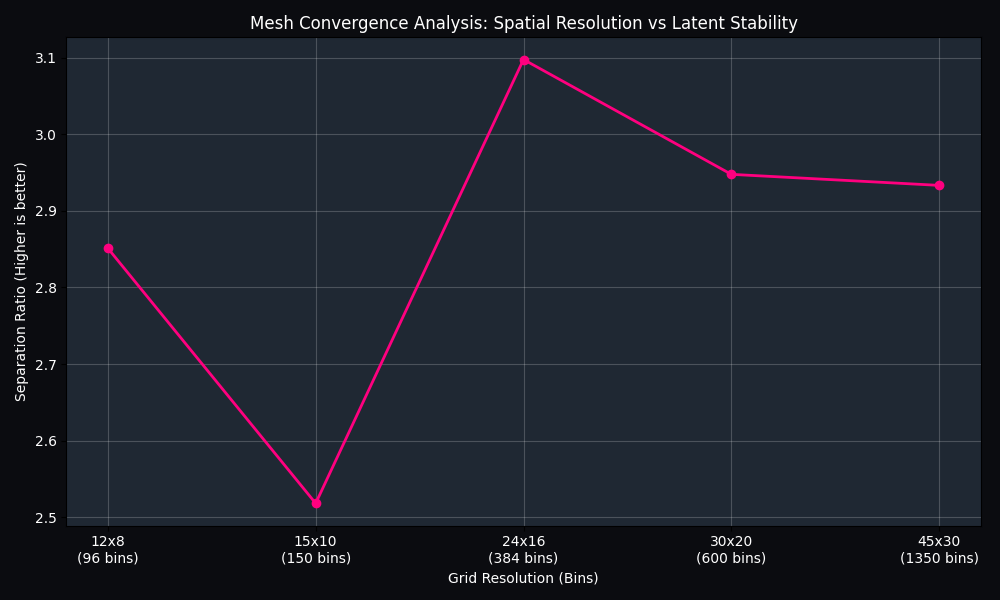

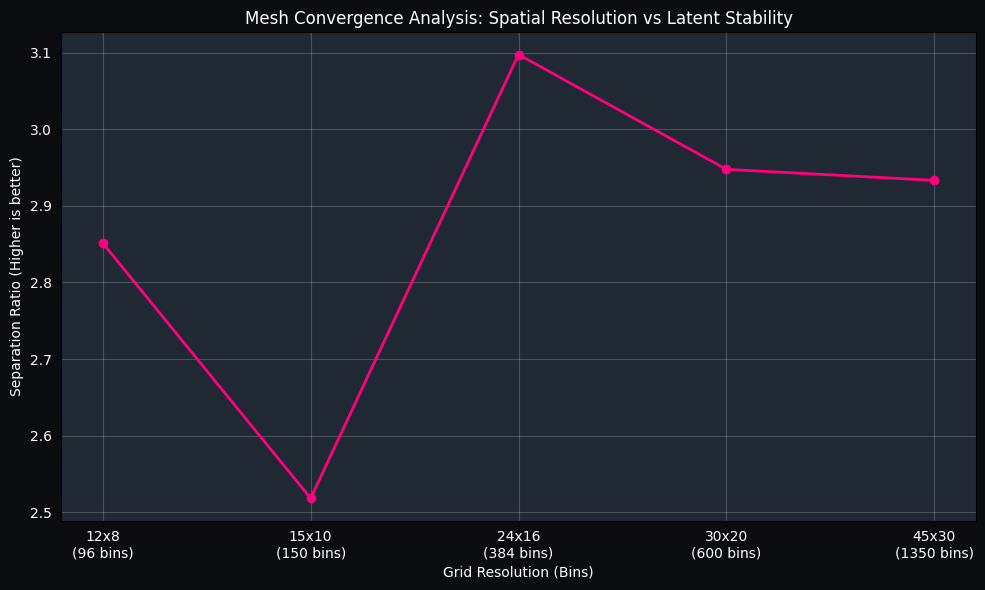

In [4]:
# Run the mesh convergence algorithm (Warning: May take 2-3 minutes to fetch match data)
# This will output a graph proving our optimal grid size.
run_mesh_convergence(match_limit=10)

# Display the generated proof
from IPython.display import Image
Image(filename='mesh_convergence.png')

---
## Phase 2: Data Ingestion & Kinematic Engineering
Based on the convergence proof above, we establish our optimal mesh at **24x16** (yielding 384 spatial dimensions). 

Next, we ingest the raw StatsBomb event data. Crucially, we pass the temporal data through our custom Kinematics Engine to calculate physics-based traits:
* $v = \frac{\sqrt{dx^2 + dy^2}}{dt}$ (Action Velocity)
* $a = \frac{dv}{dt}$ (Explosive Bursts & Braking Deceleration)

In [5]:
OPTIMAL_MESH = [24, 16]
data_path = "tactical_database.parquet"

if not os.path.exists(data_path):
    print(f"Building Dataset with {OPTIMAL_MESH[0]}x{OPTIMAL_MESH[1]} Mesh...")
    df = build_league_dataset(output_path=data_path, mesh_bins=OPTIMAL_MESH)
else:
    print("Loading pre-computed tactical dataset...")
    df = pd.read_parquet(data_path)

# Extract tactical volume keys
tactical_keys = [
    'passes_attempted', 'pass_completion_pct', 'shots', 'goals', 'assists', 
    'carries', 'dribbles', 'fouls_won', 'interceptions', 'tackles', 'clearances',
    'avg_action_velocity', 'max_action_velocity', 'explosive_bursts', 
    'total_action_distance', 'avg_deceleration'
]

# Matrix Assembly
X_spatial = np.stack(df['spatial_vector'].values)
X_tactical = np.stack(df['tactical_vector'].values)
scaler = StandardScaler()
X_tactical_scaled = scaler.fit_transform(X_tactical)

X_master = np.hstack((X_spatial, X_tactical_scaled))
player_names = df['player_name'].values

print(f"Master Matrix Assembled: {X_master.shape[0]} matches x {X_master.shape[1]} dimensions")

Building Dataset with 24x16 Mesh...
Fetching match list for Comp: 11, Season: 27...
Processing 380 matches...


100%|██████████| 380/380 [05:04<00:00,  1.25it/s]



Dataset built! Total Player-Match Vectors: 10261
Master Matrix Assembled: 10261 matches x 400 dimensions


---
## Phase 3: AI Architecture & Manifold Stability
We test two distinct architectures to reduce our massive matrix into 16 core tactical dimensions:
1. **Principal Component Analysis (PCA):** A linear baseline. Good for isolating high-variance volume stats.
2. **Variational Autoencoder (VAE):** A deep non-linear neural network built in PyTorch. Folds the spatial data to capture complex contextual behaviors.

We measure success using a custom **Separation Ratio** metric. A ratio $>1.0x$ proves the model correctly groups a player's matches together tighter than it groups them with the rest of the league.

In [6]:
print("--- Evaluating Linear Baseline (PCA) ---")
pca_model, df_pca, df_pca_centroids = train_and_extract_pca(X_master, player_names, n_components=16)
pca_same, pca_diff, pca_ratio = evaluate_manifold_stability(df_pca)
print(f"PCA Separation Ratio: {pca_ratio:.2f}x\n")

print("--- Evaluating Deep Non-Linear Manifold (VAE) ---")
X_tensor = torch.FloatTensor(X_master)
vae_model, df_vae, df_vae_centroids = train_and_extract_vae(X_tensor, player_names, input_dim=X_master.shape[1])
vae_same, vae_diff, vae_ratio = evaluate_manifold_stability(df_vae)
print(f"VAE Separation Ratio: {vae_ratio:.2f}x")

--- Evaluating Linear Baseline (PCA) ---
Training 16-Component PCA Baseline...
PCA Separation Ratio: 2.39x

--- Evaluating Deep Non-Linear Manifold (VAE) ---
Training 16D VAE on cuda for 500 epochs...
VAE Separation Ratio: 2.67x


---
## Phase 4: Production Twin Discovery
To prove the VAE's non-linear mapping works, we query the latent space for a high-profile target (Lionel Messi). 

Because the VAE folds dimensions, it ignores superficial differences (like total passes) and focuses on the *shape* of the player's behavior. We measure the Euclidean distance between centroids to find the closest statistical replica.

In [7]:
from scipy.spatial.distance import cdist

# Locate Target
target_player = [name for name in df_vae_centroids.index if "Messi" in name][0]

# Calculate latent distances
target_vector = df_vae_centroids.loc[target_player].values.reshape(1, -1)
distances = cdist(target_vector, df_vae_centroids.values, metric='euclidean').flatten()

# Normalize against the VAE's natural self-variance baseline
norm_distances = distances / vae_same

df_results = pd.DataFrame({
    'Player': df_vae_centroids.index,
    'Variance Multiplier': norm_distances
}).sort_values('Variance Multiplier')

# Filter out the target to find the twin
df_twins = df_results[df_results['Player'] != target_player]

print(f"🔍 Target Profile: {target_player}")
print(f"⭐ Closest Latent Twin: {df_twins.iloc[0]['Player']} ({df_twins.iloc[0]['Variance Multiplier']:.2f}x variance)")

display(df_twins.head(5))

🔍 Target Profile: Lionel Andrés Messi Cuccittini
⭐ Closest Latent Twin: Neymar da Silva Santos Junior (0.86x variance)


,Player,Variance Multiplier
275,Neymar da Silva Santos Junior,0.863033
68,Cristiano Ronaldo dos Santos Aveiro,2.633954
237,Luis Alberto Suárez Díaz,2.711625
242,Manuel Agudo Durán,2.862936
126,Gareth Frank Bale,2.894796


## 🏁 Conclusion & Next Steps
The Variational Autoencoder successfully maps over 400 dimensions of spatial and kinematic data into a stable, 16-dimensional footprint. 

The pipeline is now complete. The extracted centroids are routed to a front-end **Streamlit Application** allowing scouts and directors to query the entire global database in real-time.